<a href="https://colab.research.google.com/github/tarannump096-cpu/ANN/blob/main/TITANIC_DATASET_USING_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Titanic dataset
data = pd.read_csv("/content/titanic.csv")

# Display the first few rows
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [7]:
import pandas as pd

# Fill missing values in 'Age' with mean
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Check for remaining missing values
data.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
Siblings/Spouses Aboard,0
Parents/Children Aboard,0
Fare,0


In [5]:
from sklearn.preprocessing import StandardScaler

# Scaling 'Age' and 'Fare' features
scaler = StandardScaler()
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

# Display scaled features
data[['Age', 'Fare']].head()

,Age,Fare
0,-0.529366,-0.503586
1,0.604265,0.783412
2,-0.245958,-0.490020
3,0.391709,0.417948
4,0.391709,-0.487507


In [8]:
# One-hot encoding 'Sex' column
encoded_data = pd.get_dummies(data, columns=['Sex'], drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

# Define feature set (X) and target (y)
# Drop 'Survived' (target) and 'Name' (non-numeric identifier)
X = encoded_data.drop(['Survived', 'Name'], axis=1)
y = encoded_data['Survived']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert data to tensors
X_train_processed = X_train.copy()

# Convert boolean columns to integer (0 or 1) for PyTorch compatibility
for col in X_train_processed.select_dtypes(include=['bool']).columns:
    X_train_processed[col] = X_train_processed[col].astype(int)

X_train_tensor = torch.tensor(X_train_processed.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

# Create TensorDataset and DataLoader
dataset = TensorDataset(X_train_tensor, y_train_tensor)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [16]:
import torch.nn as nn
import torch.nn.functional as F

# Define the neural network model
class Net(nn.Module):
    def __init__(self, input_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, 64) # First fully connected layer
        self.fc2 = nn.Linear(64, 32)  # Second fully connected layer
        self.fc3 = nn.Linear(32, 2)   # Output layer (2 classes: Survived/Not Survived)

    def forward(self, x):
        x = F.relu(self.fc1(x)) # Apply ReLU activation to first layer output
        x = F.relu(self.fc2(x)) # Apply ReLU activation to second layer output
        x = self.fc3(x)         # Output layer (no activation here, typically done in loss function)
        return x

# Get input size from the processed training data
input_size = X_train_processed.shape[1]

# Instantiate the model
model = Net(input_size)

# Display the model architecture
print(model)

Net(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


In [17]:
# Check the number of unique classes in the target variable
num_classes = y_train.nunique()

# Get the output layer size from the model
model_output_size = model.fc3.out_features

print(f"Number of unique classes in target (y_train): {num_classes}")
print(f"Model's output layer size: {model_output_size}")

if num_classes == model_output_size:
    print("The model's output layer size matches the number of unique classes in the target variable. The architecture is compatible for this classification task.")
else:
    print("Warning: The model's output layer size does NOT match the number of unique classes in the target variable. Please adjust the model architecture or target data.")

Number of unique classes in target (y_train): 2
Model's output layer size: 2
The model's output layer size matches the number of unique classes in the target variable. The architecture is compatible for this classification task.


In [18]:
import torch.optim as optim

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

In [19]:
# Training loop
num_epochs = 100

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    for inputs, labels in data_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training complete!")

Epoch [1/100], Loss: 0.6107
Epoch [2/100], Loss: 0.6115
Epoch [3/100], Loss: 0.5268
Epoch [4/100], Loss: 0.4733
Epoch [5/100], Loss: 0.9237
Epoch [6/100], Loss: 0.3883
Epoch [7/100], Loss: 0.6539
Epoch [8/100], Loss: 0.3103
Epoch [9/100], Loss: 0.7786
Epoch [10/100], Loss: 0.1826
Epoch [11/100], Loss: 0.8147
Epoch [12/100], Loss: 0.4982
Epoch [13/100], Loss: 0.1734
Epoch [14/100], Loss: 0.1731
Epoch [15/100], Loss: 0.5147
Epoch [16/100], Loss: 0.2875
Epoch [17/100], Loss: 0.3110
Epoch [18/100], Loss: 0.3304
Epoch [19/100], Loss: 0.1996
Epoch [20/100], Loss: 0.1467
Epoch [21/100], Loss: 0.2202
Epoch [22/100], Loss: 0.3650
Epoch [23/100], Loss: 0.7905
Epoch [24/100], Loss: 0.1159
Epoch [25/100], Loss: 0.4294
Epoch [26/100], Loss: 0.1585
Epoch [27/100], Loss: 0.3441
Epoch [28/100], Loss: 0.2664
Epoch [29/100], Loss: 0.1076
Epoch [30/100], Loss: 0.3876
Epoch [31/100], Loss: 0.0849
Epoch [32/100], Loss: 0.1629
Epoch [33/100], Loss: 0.1343
Epoch [34/100], Loss: 0.1347
Epoch [35/100], Loss: 0

In [20]:
# Prepare X_test for tensor conversion (handle boolean columns)
X_test_processed = X_test.copy()

for col in X_test_processed.select_dtypes(include=['bool']).columns:
    X_test_processed[col] = X_test_processed[col].astype(int)

# Convert test data to tensors
X_test_tensor = torch.tensor(X_test_processed.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create TensorDataset and DataLoader for the test set
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # No need to shuffle test data

print("Test data prepared and converted to PyTorch tensors and DataLoader.")

Test data prepared and converted to PyTorch tensors and DataLoader.


Accuracy: 0.7978
Precision: 0.7925
Recall: 0.6269
F1 Score: 0.7000


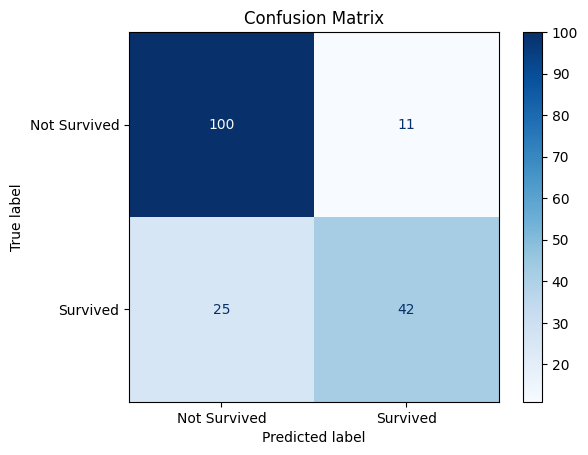

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Evaluate the model on the test set
model.eval() # Set the model to evaluation mode
all_predictions = []
all_labels = []

with torch.no_grad(): # Disable gradient calculation during evaluation
    for inputs, labels in test_data_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average='binary')
recall = recall_score(all_labels, all_predictions, average='binary')
f1 = f1_score(all_labels, all_predictions, average='binary')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualize Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Now that the model is trained, we can prepare the test data and evaluate its performance.